# Detect Small Objects in Aerial Imagery with Oriented Bounding Boxes

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/roboflow/supervision/blob/develop/docs/notebooks/small-object-detection-with-obb.ipynb)
[![arXiv](https://img.shields.io/badge/arXiv-2202.06934-b31b1b.svg)](https://arxiv.org/abs/2202.06934)

Aerial and satellite imagery rarely cooperates with axis-aligned bounding boxes. Ships dock at an angle, trucks follow curved roads, and planes park nose-in - the objects are rotated, elongated, and tiny relative to the frame. This cookbook walks through a complete oriented bounding box (OBB) pipeline on a real harbor scene: detecting with a DOTA-pretrained model, slicing the image with [SAHI](https://arxiv.org/abs/2202.06934) to recover small objects, de-duplicating with oriented NMS, filtering by real object footprint, and exporting the results as a YOLO OBB dataset.

## Install required packages

We need two packages:

*   `supervision`: utilities for working with detections - slicing, NMS, annotation, dataset export. This cookbook requires version `0.29.0` or newer.
*   `ultralytics`: provides YOLO11-OBB models pretrained on [DOTA](https://captain-whu.github.io/DOTA/), an aerial imagery dataset with oriented annotations.

In [1]:
%pip install -q "supervision>=0.29.0rc0" ultralytics

Note: you may need to restart the kernel to use updated packages.


In [2]:
import cv2
import numpy as np
import supervision as sv
from ultralytics import YOLO

print(sv.__version__)

0.29.0rc0


## Download the image

We will work with an aerial photograph of the Bremerhaven container terminal - one of the busiest container ports in Europe. The full image is 5400 x 3300 pixels and contains hundreds of ships, trucks and harbor structures.

Photo by [Carsten Steger](https://commons.wikimedia.org/wiki/File:Aerial_image_of_the_Bremerhaven_container_terminal_%28view_from_the_southeast%29.jpg), licensed under CC BY-SA 4.0.

Image shape: 5400w x 3300h


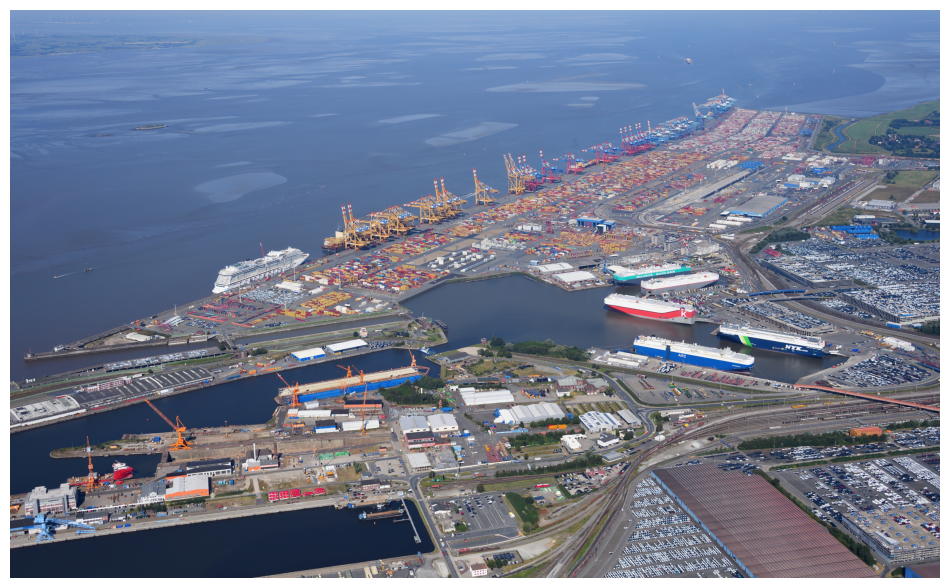

In [3]:
import urllib.request

IMAGE_URL = (
    "https://upload.wikimedia.org/wikipedia/commons/8/86/Aerial_image_of_the_Bremerhaven_container_terminal_%28view_from_the_southeast%29.jpg"
)
request = urllib.request.Request(IMAGE_URL, headers={"User-Agent": "supervision-cookbook"})
with urllib.request.urlopen(request) as response, open("terminal.jpg", "wb") as file:
    file.write(response.read())

image = cv2.imread("terminal.jpg")
image_wh = (image.shape[1], image.shape[0])
print(f"Image shape: {image_wh[0]}w x {image_wh[1]}h")
sv.plot_image(image, size=(12, 8))

## Baseline: running the model on the full image

Let's start with the obvious approach - feed the entire image to the model. We use `yolo11n-obb`, the smallest YOLO11 variant trained on DOTA. Its classes include `ship`, `small vehicle`, `large vehicle`, `harbor`, `storage tank` and other aerial categories. The model resizes its input to 1024 px on the longest side, which means each ship in our 5400 px wide photo shrinks to just a few pixels.

In [4]:
model = YOLO("yolo11n-obb.pt")

result = model(image, imgsz=1024, verbose=False)[0]
detections = sv.Detections.from_ultralytics(result)

print(f"Detections: {len(detections)}")

Detections: 3


Three detections - in an image that visibly contains hundreds of vehicles and dozens of vessels. After the resize to 1024 px, most objects are simply too small for the model to see.

Before fixing that, let's look at what an OBB detection carries. Alongside the usual axis-aligned `xyxy` box, the four corners of the rotated box are stored in `detections.data["xyxyxyxy"]` as an `(N, 4, 2)` array:

In [5]:
print("xyxy (axis-aligned):")
print(detections.xyxy[0])
print()
print('data["xyxyxyxy"] (rotated corners):')
print(detections.data["xyxyxyxy"][0])

xyxy (axis-aligned):
[     2022.5      2912.4      2156.1        2955]

data["xyxyxyxy"] (rotated corners):
[[     2025.9        2955]
 [     2156.1        2936]
 [     2152.7      2912.4]
 [     2022.5      2931.4]]


The rotated corners are what `OrientedBoxAnnotator` draws, and - as we will see below - what supervision uses to compare detections whenever they are present. For a long thin ship docked at 45 degrees, the axis-aligned box is mostly water; the oriented box hugs the hull.

## Slicing the image with `InferenceSlicer`

[SAHI](https://arxiv.org/abs/2202.06934) (Slicing Aided Hyper Inference) runs the model on overlapping tiles of the image instead of the full frame, so small objects appear large enough to detect. `sv.InferenceSlicer` handles the tiling, runs a callback on every tile, and moves all detections - boxes, masks and oriented corners alike - back into full-image coordinates.

One setting matters a lot in scenes this dense: ultralytics caps each inference call at 300 detections by default, and a single 1024 px tile of the vehicle storage rows contains over 500 objects. We raise `max_det` in the callback so the cap never bites.

If an object sits right on a tile border, its rotated corners can extend a few pixels past the tile, and supervision prints a one-time warning about slice bounds. With oriented detections this is expected - the corners are still mapped back to full-image coordinates correctly.

We start with `overlap_filter=sv.OverlapFilter.NONE` to see the raw, un-deduplicated output:

In [6]:
def callback(image_slice: np.ndarray) -> sv.Detections:
    result = model(image_slice, imgsz=1024, verbose=False, max_det=2000)[0]
    return sv.Detections.from_ultralytics(result)


slicer = sv.InferenceSlicer(
    callback=callback,
    slice_wh=(1024, 1024),
    overlap_wh=(128, 128),
    overlap_filter=sv.OverlapFilter.NONE,
)

raw_detections = slicer(image)
print(f"Detections: {len(raw_detections)}")

SupervisionWarnings: Detections returned by the callback have coordinates outside the slice bounds. This may be caused by the callback running inference on the full image instead of the provided image slice. Ensure your callback uses the input slice for inference, not the original full-resolution image.


Detections: 957


957 detections, up from 3. Slicing transformed the model's view of the scene.

Because neighbouring tiles overlap by 128 px, objects near tile boundaries are detected twice. Let's zoom into a seam to see the duplicates:

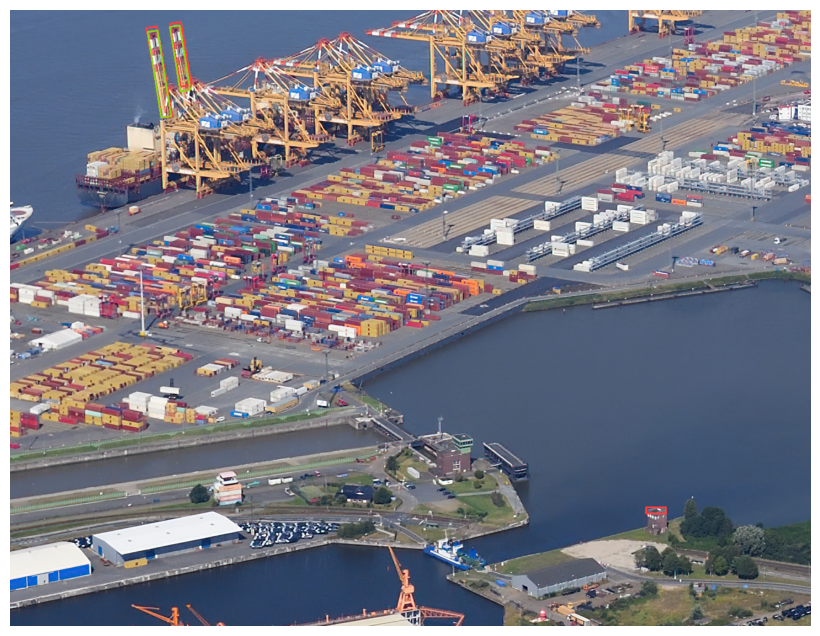

In [7]:
oriented_box_annotator = sv.OrientedBoxAnnotator(thickness=2)

annotated = oriented_box_annotator.annotate(scene=image.copy(), detections=raw_detections)
sv.plot_image(annotated[1100:2100, 1700:3000], size=(12, 8))

## De-duplicating with oriented NMS

`Detections.with_nms` removes duplicates by suppressing overlapping detections. When the detections carry oriented corners, the overlap is computed between the rotated bodies rather than the axis-aligned boxes - exactly what densely packed, angled objects need:

In [8]:
detections = raw_detections.with_nms(threshold=0.3)
print(f"Detections: {len(detections)}")

class_names, counts = np.unique(detections.data["class_name"], return_counts=True)
print(dict(zip(class_names.tolist(), counts.tolist())))

Detections: 590
{'bridge': 1, 'harbor': 10, 'large vehicle': 100, 'ship': 41, 'small vehicle': 436, 'storage tank': 2}


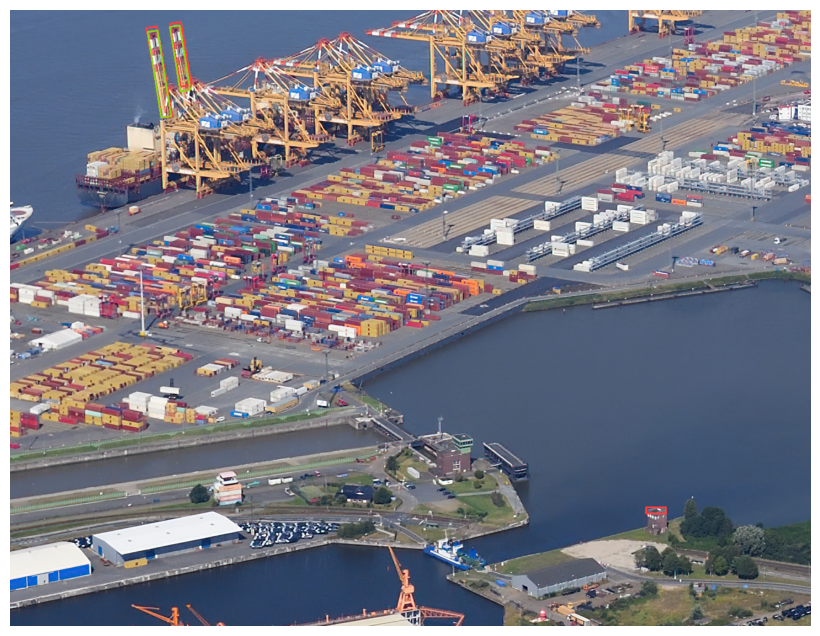

In [9]:
annotated = oriented_box_annotator.annotate(scene=image.copy(), detections=detections)
sv.plot_image(annotated[1100:2100, 1700:3000], size=(12, 8))

590 detections remain: 436 small vehicles, 100 large vehicles, 41 ships, plus harbor structures. The seam duplicates are gone.

### Why oriented overlap matters here

In a packed harbor, the axis-aligned boxes of two ships moored side by side at an angle overlap substantially even though their hulls never touch. If NMS compared those axis-aligned boxes, it would treat neighbours as duplicates and suppress real ships. We can demonstrate this by dropping the oriented corners and re-running NMS on the same raw detections:

In [10]:
aabb_detections = sv.Detections(
    xyxy=raw_detections.xyxy.copy(),
    confidence=raw_detections.confidence.copy(),
    class_id=raw_detections.class_id.copy(),
    data={"class_name": raw_detections.data["class_name"].copy()},
)

aabb_nms = aabb_detections.with_nms(threshold=0.3)
print(f"Axis-aligned NMS: {len(aabb_nms)} detections")
print(f"Oriented NMS:     {len(detections)} detections")

Axis-aligned NMS: 559 detections
Oriented NMS:     590 detections


The net difference is 31 detections, but the disagreement is larger: 67 detections kept by oriented NMS are missing from the axis-aligned result. Let's mark them in red over the densest corner of the scene - the vehicle storage rows next to the terminal:

Detections lost to axis-aligned NMS: 67


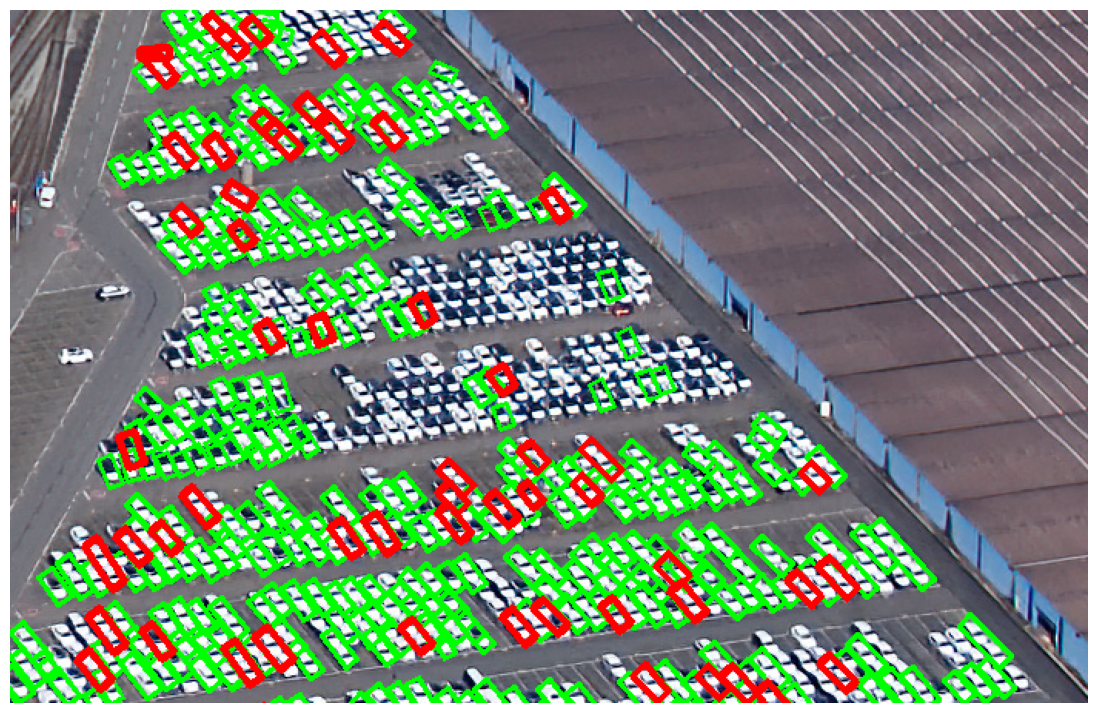

In [11]:
kept_by_aabb = (detections.xyxy[:, None] == aabb_nms.xyxy[None]).all(axis=-1).any(axis=-1)
suppressed = detections[~kept_by_aabb]
print(f"Detections lost to axis-aligned NMS: {len(suppressed)}")

annotated = sv.OrientedBoxAnnotator(color=sv.Color.GREEN, thickness=2).annotate(
    scene=image.copy(), detections=detections
)
annotated = sv.OrientedBoxAnnotator(color=sv.Color.RED, thickness=4).annotate(
    scene=annotated, detections=suppressed
)
sv.plot_image(annotated[2784:3234, 3532:4232], size=(14, 9))

Every red box is a separate, real vehicle or vessel that survives oriented NMS but gets suppressed when only envelopes are compared. Parked in diagonal rows, each car's axis-aligned envelope overlaps its neighbour's enough to look like a duplicate - over 5% of the scene disappears this way. The cars with no box at all are a different story: the nano model scores them below its default confidence threshold, and lowering `conf` in the callback recovers many of them at the cost of more false positives elsewhere. That trade-off does not affect this comparison, which only concerns what NMS keeps from the raw detections.

In practice you do not need the two-step version above - `InferenceSlicer` applies the same oriented NMS internally when you pass `overlap_filter=sv.OverlapFilter.NON_MAX_SUPPRESSION`:

In [12]:
slicer = sv.InferenceSlicer(
    callback=callback,
    slice_wh=(1024, 1024),
    overlap_wh=(128, 128),
    overlap_filter=sv.OverlapFilter.NON_MAX_SUPPRESSION,
    iou_threshold=0.3,
)

detections = slicer(image)
print(f"Detections: {len(detections)}")

SupervisionWarnings: Detections returned by the callback have coordinates outside the slice bounds. This may be caused by the callback running inference on the full image instead of the provided image slice. Ensure your callback uses the input slice for inference, not the original full-resolution image.


Detections: 590


## Filtering by real footprint

For oriented detections, `detections.area` returns the area of the rotated body - not the axis-aligned envelope, which would overestimate badly for long diagonal objects. This makes it a reliable filter for separating vessels by size:

In [13]:
ships = detections[detections.data["class_name"] == "ship"]
print(f"Ships: {len(ships)}")
print(f"Footprint (px^2): min {ships.area.min():.0f}, median {np.median(ships.area):.0f}, max {ships.area.max():.0f}")

large_vessels = ships[ships.area > 1000]
print(f"Ships larger than 1000 px^2: {len(large_vessels)}")

Ships: 41
Footprint (px^2): min 58, median 440, max 2607
Ships larger than 1000 px^2: 6


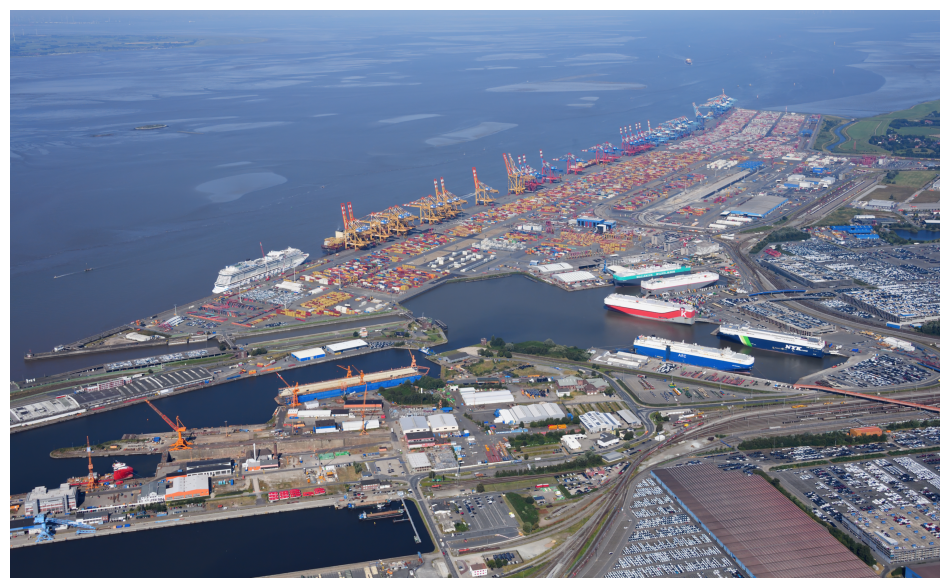

In [14]:
annotated = oriented_box_annotator.annotate(scene=image.copy(), detections=large_vessels)
sv.plot_image(annotated, size=(12, 8))

## Exporting as a YOLO OBB dataset

Finally, let's turn the detections into training data. `DetectionDataset.as_yolo` with `is_obb=True` writes the rotated corners in the 9-token YOLO OBB format (`class x1 y1 x2 y2 x3 y3 x4 y4`, normalized), which `ultralytics` can train on directly - handy for bootstrapping labels on a new aerial dataset:

In [15]:
import os

os.makedirs("dataset/images", exist_ok=True)
cv2.imwrite("dataset/images/terminal.jpg", image)

classes = sorted(set(detections.data["class_name"].tolist()))
name_to_id = {name: idx for idx, name in enumerate(classes)}
export = sv.Detections(
    xyxy=detections.xyxy,
    confidence=detections.confidence,
    class_id=np.array([name_to_id[name] for name in detections.data["class_name"]]),
    data=dict(detections.data),
)

dataset = sv.DetectionDataset(
    classes=classes,
    images=["dataset/images/terminal.jpg"],
    annotations={"dataset/images/terminal.jpg": export},
)
dataset.as_yolo(annotations_directory_path="dataset/labels", is_obb=True)

with open("dataset/labels/terminal.txt") as f:
    first_line = f.readline().strip()
print(f"{len(open('dataset/labels/terminal.txt').readlines())} annotations written")
print(f"First line ({len(first_line.split())} tokens): {first_line[:80]}...")

590 annotations written
First line (9 tokens): 3 0.19920 0.02359 0.19926 0.02123 0.19252 0.02080 0.19246 0.02315...


## Conclusion

Starting from a model that found 3 objects in a 5400 px harbor photo, slicing with `InferenceSlicer` and de-duplicating with oriented NMS brought us to 590, covering the terminal's vehicle rows, vessels and infrastructure. Along the way we used the oriented corners for everything they are good for: comparing rotated bodies instead of axis-aligned envelopes, measuring real object footprints, and exporting training-ready YOLO OBB annotations. The same recipe applies to any aerial or satellite workload where objects are small, dense, and stubbornly diagonal.

## More resources

- `InferenceSlicer`: https://supervision.roboflow.com/latest/detection/tools/inference_slicer/
- Detect Small Objects (axis-aligned version of this cookbook): https://supervision.roboflow.com/latest/notebooks/small-object-detection-with-sahi/
- YOLO11 OBB models: https://docs.ultralytics.com/tasks/obb/
- DOTA dataset: https://captain-whu.github.io/DOTA/
- SAHI paper: https://arxiv.org/abs/2202.06934